# Phase 2: Detail Toggle & Model Downgrade

**Objective:** Run the same chaotic image from Phase 1 through 4 combinations and compare quality vs cost trade-offs.

| Combination | Model | Detail |
|---|---|---|
| A | gpt-4.1-mini | low |
| B | gpt-4.1-nano | high |
| C (rotated) | gpt-4.1-mini | low |
| D (rotated) | gpt-4.1-nano | high |

**Setup:** Uses the same image from `resources/phase1/` - no separate folder needed.

---

In [8]:
# !pip install openai pillow python-dotenv -q

In [9]:
import os
import base64
import io
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [10]:
load_dotenv()

OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', '')
if not OPENAI_API_KEY:
    raise ValueError('OPENAI_API_KEY not found. Fill it in .env and re-run.')

client = OpenAI(api_key=OPENAI_API_KEY)
print('OpenAI client ready.')

OpenAI client ready.


In [11]:
# ── Load Phase 1 image ────────────────────────────────────────────────────────
def find_image(folder):
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        matches = list(Path(folder).glob(ext))
        if matches:
            return matches[0]
    raise FileNotFoundError(f'No PNG or JPEG image found in {folder}')

IMAGE_PATH = find_image('resources/phase1')
img_original = Image.open(IMAGE_PATH).convert('RGB')
W, H = img_original.size
print(f'Loaded: {IMAGE_PATH.name}  |  {W} x {H} px')

Loaded: chaotic.png  |  1536 x 1024 px


Rotated size: 1024 x 1536 px


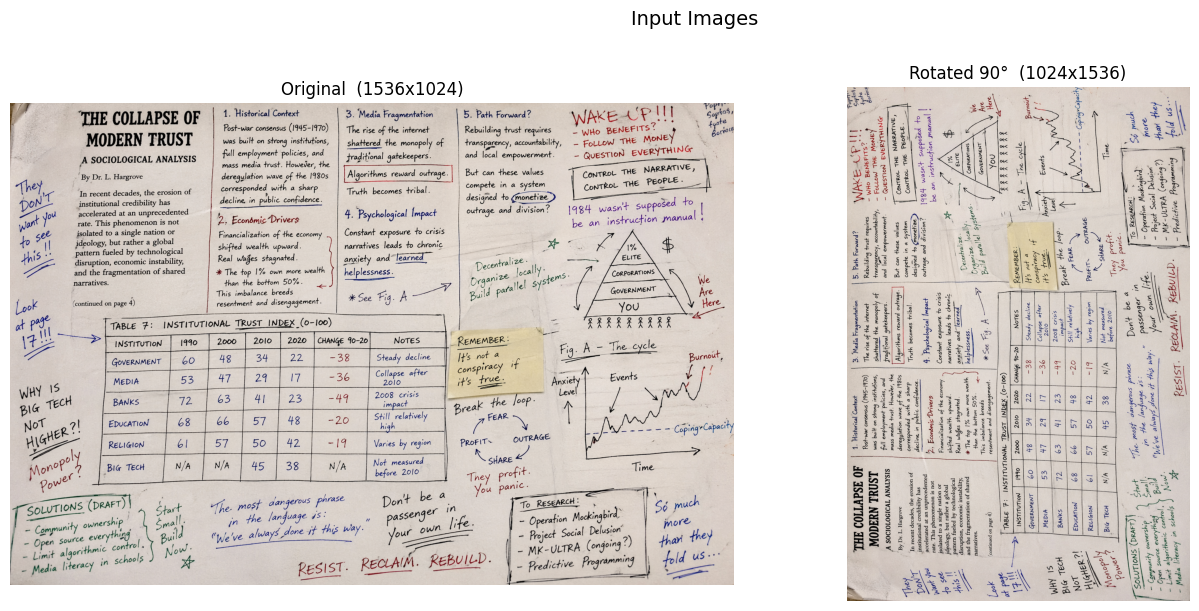

In [12]:
# ── Create 90-degree rotated version ─────────────────────────────────────────
img_rotated = img_original.rotate(90, expand=True)
Wr, Hr = img_rotated.size
print(f'Rotated size: {Wr} x {Hr} px')

# Display original and rotated side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_original)
axes[0].set_title(f'Original  ({W}x{H})', fontsize=12)
axes[0].axis('off')
axes[1].imshow(img_rotated)
axes[1].set_title(f'Rotated 90°  ({Wr}x{Hr})', fontsize=12)
axes[1].axis('off')
plt.suptitle('Input Images', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# ── Helper functions ──────────────────────────────────────────────────────────
MIME_MAP = {'jpg': 'jpeg', 'jpeg': 'jpeg', 'png': 'png'}

def pil_to_b64(pil_img, fmt='PNG'):
    buf = io.BytesIO()
    pil_img.save(buf, format=fmt)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

def call_vision(image_b64, mime, model, detail, prompt):
    data_url = f'data:image/{mime};base64,{image_b64}'
    resp = client.chat.completions.create(
        model=model,
        messages=[{
            'role': 'user',
            'content': [
                {'type': 'image_url', 'image_url': {'url': data_url, 'detail': detail}},
                {'type': 'text', 'text': prompt}
            ]
        }],
        max_tokens=1200
    )
    return resp.choices[0].message.content, resp.usage

EVAL_PROMPT = """Analyze this document image and:
1. Transcribe all visible text, preserving multi-column layout with [COLUMN 1] / [COLUMN 2] labels.
2. Reproduce any table using | separators.
3. Transcribe handwritten text exactly as written, prefixed with [HANDWRITTEN].
4. Note any text or structure you cannot read clearly."""

# Pre-encode both images
b64_original = pil_to_b64(img_original)
b64_rotated  = pil_to_b64(img_rotated)
print('Images encoded. Ready to run combinations.')

Images encoded. Ready to run combinations.


## Running All 4 Combinations

Each cell runs one combination and prints the model response plus token usage.

In [14]:
# Combination A: Original + gpt-4.1-mini + detail:low
print('Running Combination A: gpt-4.1-mini | detail:low | ORIGINAL image')
print('=' * 65)
resp_A, usage_A = call_vision(b64_original, 'png', 'gpt-4.1-mini', 'low', EVAL_PROMPT)
print(resp_A)
print(f'\nTokens - prompt: {usage_A.prompt_tokens}, completion: {usage_A.completion_tokens}, total: {usage_A.total_tokens}')

Running Combination A: gpt-4.1-mini | detail:low | ORIGINAL image
Transcription follows, preserving columns and tables, and indicating handwritten text exactly as is.

---

**THE COLLAPSE OF MODERN TRUST**  
**A SOCIOLOGICAL ANALYSIS**   
By Dr. L. Hargrove  

In recent decades, the erosion of institutional credibility has accelerated at an unprecedented rate. This phenomenon is not isolated to a single nation or ideology, but rather a global pattern fueled by technological disruption, economic instability, and the fragmentation of shared narratives.  

(continued on page 4)

---

**[COLUMN 1]**

**1. Historical Context**  
Post-war consensus (1945-1970) was built on strong institutions, full employment policies, and mass media trust. However, the deregulation wave of the 1980s corresponded with a sharp decline in public confidence.

**2. Economic Drivers**  
Financialization of the economy shifted wealth upward. Real wages stagnated.  
* The top 1% own more wealth than the bottom 50%.

In [15]:
# Combination B: Original + gpt-4.1-nano + detail:high
print('Running Combination B: gpt-4.1-nano | detail:high | ORIGINAL image')
print('=' * 65)
resp_B, usage_B = call_vision(b64_original, 'png', 'gpt-4.1-nano', 'high', EVAL_PROMPT)
print(resp_B)
print(f'\nTokens - prompt: {usage_B.prompt_tokens}, completion: {usage_B.completion_tokens}, total: {usage_B.total_tokens}')

Running Combination B: gpt-4.1-nano | detail:high | ORIGINAL image
Certainly! Here's the detailed transcription of the document with the specified formatting:

---

**[COLUMN 1]**

**THE COLLAPSE OF MODERN TRUST**  
**A SOCIOLOGICAL ANALYSIS**  
By Dr. L. Hargrove

In recent decades, the erosion of institutional credibility has accelerated at an unprecedented rate. This phenomenon is not isolated to a single nation or ideology, but rather a global pattern fueled by technological disruption, economic instability, and the fragmentation of shared narratives.

(continued on page 4)

**Look at page 17!!!** (handwritten in blue)

**WHY IS BIG TECH NOT HIGHER?!**  
Monopoly Power? (handwritten in red)

**SOLUTIONS (DRAFT)** (handwritten in green)  
- Community ownership  
- Open source everything  
- Limit algorithmic control.  
- Media literacy in schools  
[HANDWRITTEN]  
Start Small. Build Now.

**[COLUMN 2]**

[CONTINUATION FROM PAGE 1 / SINGLE COLUMN OR DEEPER TEXT BEYOND PAGE 4]

---

*

In [16]:
# Combination C: Rotated + gpt-4.1-mini + detail:low
print('Running Combination C: gpt-4.1-mini | detail:low | ROTATED image')
print('=' * 65)
resp_C, usage_C = call_vision(b64_rotated, 'png', 'gpt-4.1-mini', 'low', EVAL_PROMPT)
print(resp_C)
print(f'\nTokens - prompt: {usage_C.prompt_tokens}, completion: {usage_C.completion_tokens}, total: {usage_C.total_tokens}')

Running Combination C: gpt-4.1-mini | detail:low | ROTATED image
Here is the transcription of the document image, maintaining the multi-column layout, with the table reproduced using | separators, and including handwritten text with the [HANDWRITTEN] prefix:

---

**THE COLLAPSE OF MODERN TRUST**  
**A SOCIOLOGICAL ANALYSIS**  
_By Dr. L. Hargrove_  
In recent decades, the erosion of institutional trust has  
increased dramatically at an unprecedented  
rate. This phenomenon is not purely an  
isolated sociological problem, but rather a global  
pattern fueled by technological  
disruption, economic instability,  
and the fragmentation of shared  
narratives.  
(continued on page 4)

---

**1. Historical Context**  
Post-war consensus (1945–1970)  
was built on strong institutions,  
full employment policies, and  
mass media trust. However, the  
deregulation wave of the 1980s  
responded with sharp  
decline in public confidence.

**2. Economic Drivers**  
Financialization of the eco

In [17]:
# Combination D: Rotated + gpt-4.1-nano + detail:high
print('Running Combination D: gpt-4.1-nano | detail:high | ROTATED image')
print('=' * 65)
resp_D, usage_D = call_vision(b64_rotated, 'png', 'gpt-4.1-nano', 'high', EVAL_PROMPT)
print(resp_D)
print(f'\nTokens - prompt: {usage_D.prompt_tokens}, completion: {usage_D.completion_tokens}, total: {usage_D.total_tokens}')

Running Combination D: gpt-4.1-nano | detail:high | ROTATED image
Certainly! Here is the detailed transcription of the image:

---

**[COLUMN 1]**

**The Collapse of Modern Trust**

A sociological analysis  
By Dr. J. Hargrove

In recent decades, the rise of the internet & social media has drastically dismantledTraditionally, the trust institution & mass media in the 2008 decline with public confidence.

The narrative becomes tribal, Algorithm becomes tribal impact truth becomes tribal impact narratives lead to crisis anxiety and learned helplessness!

**3. Media Fragmentation**  
The rise of the internet & social media has dramatically fragmented traditional gatekeepers.  
Truth becomes tribal, impact narratives lead to crisis anxiety & learned helplessness!

**4. Psychological Impact**  
Constant exposure to outrage narratives leads to anxiety and learned helplessness!

---

**[COLUMN 2]**

**5. Path Forward?**  
- Rebuild trust!  
- Follow the narrative question:  
"1984 wasn’t supp

In [18]:
# Token Usage Summary
print('\n=== TOKEN USAGE SUMMARY ===')
print(f'{"Combo":<6} {"Model":<15} {"Detail":<8} {"Image":<10} {"Prompt Tok":>11} {"Compl Tok":>10} {"Total":>8}')
print('-' * 70)
rows = [
    ('A', 'gpt-4.1-mini', 'low',  'Original', usage_A),
    ('B', 'gpt-4.1-nano', 'high', 'Original', usage_B),
    ('C', 'gpt-4.1-mini', 'low',  'Rotated',  usage_C),
    ('D', 'gpt-4.1-nano', 'high', 'Rotated',  usage_D),
]
for combo, model, detail, img_label, u in rows:
    print(f'{combo:<6} {model:<15} {detail:<8} {img_label:<10} {u.prompt_tokens:>11,} {u.completion_tokens:>10,} {u.total_tokens:>8,}')


=== TOKEN USAGE SUMMARY ===
Combo  Model           Detail   Image       Prompt Tok  Compl Tok    Total
----------------------------------------------------------------------
A      gpt-4.1-mini    low      Original         2,570      1,167    3,737
B      gpt-4.1-nano    high     Original         3,860      1,047    4,907
C      gpt-4.1-mini    low      Rotated          2,570      1,198    3,768
D      gpt-4.1-nano    high     Rotated          3,860        708    4,568


---

## Phase 2 - Questions & Observations

### Q1: What information was lost when using `detail: low`?

**Answer:** Combo A (4.1-mini, low) vs Combo B (4.1-nano, high) on the original image:

- detail: low missed the post-it note ("REMEMBER: It's not a conspiracy if it's true") — Combo B caught it, Combo A did not
- detail: low collapsed column attribution — Combo A used a single narrative flow with section headers, while Combo B attempted more granular column separation
- detail: low missed inline color cues — Combo B identified text colors (blue, red, green handwriting), Combo A did not

Prompt tokens dropped from 3860 → 2570 (33% fewer tokens) confirming the image was downsampled significantly
Both detail levels successfully extracted the full table with all values intact, meaning the table was large enough to survive downsampling

---

### Q2: How did `gpt-4.1-nano` compare to `gpt-4.1-mini` in layout understanding?

**Answer:** 
- gpt-4.1-mini (Combo A) produced cleaner, more structured output — clear section headings, clean table, well-labelled handwritten blocks
- gpt-4.1-nano (Combo B) hallucinated layout — invented a "[CONTINUATION FROM PAGE 1 / SINGLE COLUMN OR DEEPER TEXT BEYOND PAGE 4]" section that doesn't exist, and placed column labels inconsistently mid-document
- gpt-4.1-nano added unsolicited filler ("If you need further detailed structure, let me know!") despite the prompt saying not to
- gpt-4.1-nano used more prompt tokens (3860 vs 2570) due to detail:high, yet produced less accurate structure — showing that more tokens ≠ better layout reasoning, model capability matters more

---

### Q3: How did both models handle the rotated images?

**Answer:** 
- Both models successfully read the rotated image — neither refused or flagged the orientation, and both extracted the full table correctly
- gpt-4.1-mini (Combo C) handled rotation remarkably well — output was nearly identical in quality to Combo A, with only minor differences (e.g. "Collapse after 2008 crisis" instead of "Collapse after 2010" in the MEDIA notes row — a small hallucination)
- gpt-4.1-nano (Combo D) degraded significantly under rotation — the table lost two data columns (1990 and CHANGE 90-20 columns were dropped entirely), column counts jumped to 7 invented columns, and several handwritten quotes were paraphrased or invented rather than transcribed exactly
- Conclusion: gpt-4.1-mini shows stronger spatial robustness to rotation; gpt-4.1-nano's layout understanding breaks down more severely when the reading orientation is non-standard